RGB图片+一个卷积核

in_channels：决定每个 Filter 内部有多少个二维通道卷积核。


out_channels：决定整层有多少个 Filter，也就是最终输出多少张特征图。


kernel_size：决定每个二维卷积核的空间大小，例如 \(3\times3\) 或 \(5\times5\)。

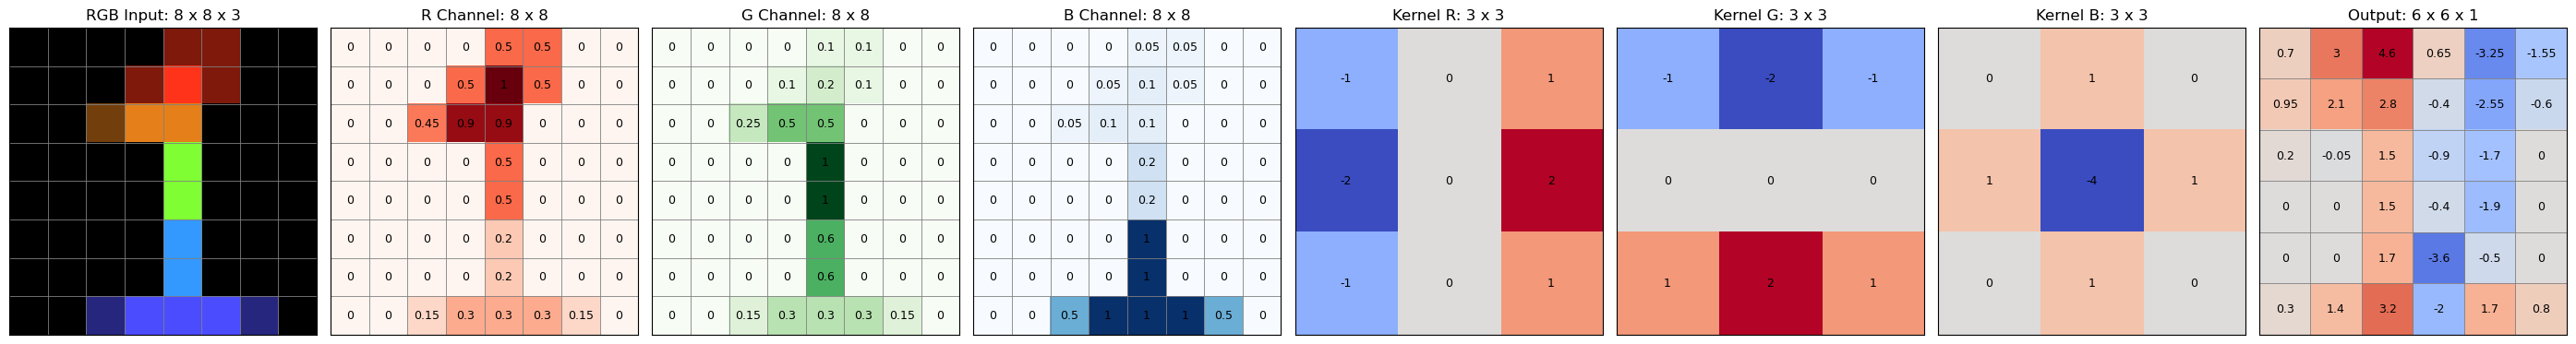

输入尺寸: (1, 3, 8, 8)
Filter 权重尺寸: (1, 3, 3, 3)
输出尺寸: (1, 1, 6, 6)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [18]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display, Math

# 1. 构造 8×8 手写数字 1
image = torch.tensor([
    [0,0,0,0,0.5,0.5,0,0],
    [0,0,0,0.5,1,0.5,0,0],
    [0,0,0.5,1,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0.5,1,1,1,0.5,0]
], dtype=torch.float32)

# 2. 为数字的不同位置设置 RGB 颜色，生成 8×8×3 彩色图像
row_colors = torch.tensor([
    [1.0,0.2,0.1],
    [1.0,0.2,0.1],
    [0.9,0.5,0.1],
    [0.5,1.0,0.2],
    [0.5,1.0,0.2],
    [0.2,0.6,1.0],
    [0.2,0.6,1.0],
    [0.3,0.3,1.0]
], dtype=torch.float32)

rgb = image.unsqueeze(-1) * row_colors.unsqueeze(1)
x = rgb.permute(2,0,1).unsqueeze(0)  # [Batch, Channels, Height, Width] = [1,3,8,8]

# 3. 定义一个 Filter，其中包含三个 3×3 卷积核，分别对应 R、G、B
kernel_R = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32)
kernel_G = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32)
kernel_B = torch.tensor([[0,1,0],[1,-4,1],[0,1,0]], dtype=torch.float32)

kernels = torch.stack([kernel_R,kernel_G,kernel_B])
conv = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, stride=1, padding=0, bias=False)

# 4. 三个通道分别卷积，再求和，得到最终特征图
with torch.no_grad():
    conv.weight.copy_(kernels.unsqueeze(0))
    y = conv(x)

    F_R = F.conv2d(x[:,0:1], kernel_R.reshape(1,1,3,3))[0,0]
    F_G = F.conv2d(x[:,1:2], kernel_G.reshape(1,1,3,3))[0,0]
    F_B = F.conv2d(x[:,2:3], kernel_B.reshape(1,1,3,3))[0,0]

    assert torch.allclose(y[0,0], F_R+F_G+F_B)

# 5. 绘制矩阵，每个像素显示对应数值
def show_matrix(ax, data, title, cmap="coolwarm"):
    a = data.detach().cpu().numpy()
    vmax = max(1, np.abs(a).max())
    positive = cmap in ["Reds","Greens","Blues"]
    ax.imshow(a, cmap=cmap, vmin=0 if positive else -vmax, vmax=1 if positive else vmax)

    for i in range(a.shape[0]):
        for j in range(a.shape[1]):
            ax.text(j,i,f"{a[i,j]:g}",ha="center",va="center",fontsize=9,color="black")

    ax.set_xticks(np.arange(-0.5,a.shape[1],1),minor=True)
    ax.set_yticks(np.arange(-0.5,a.shape[0],1),minor=True)
    ax.grid(which="minor",color="gray",linewidth=0.6)
    ax.tick_params(which="both",bottom=False,left=False,labelbottom=False,labelleft=False)
    ax.set_title(title,fontsize=12)

# 6. 绘制原始 RGB 彩色图片
def show_rgb(ax, data, title):
    a = data.detach().cpu().numpy()
    ax.imshow(a)
    ax.set_xticks(np.arange(-0.5,8,1),minor=True)
    ax.set_yticks(np.arange(-0.5,8,1),minor=True)
    ax.grid(which="minor",color="gray",linewidth=0.6)
    ax.tick_params(which="both",bottom=False,left=False,labelbottom=False,labelleft=False)
    ax.set_title(title,fontsize=12)

# 7. 所有图在同一行显示
fig, axes = plt.subplots(1,8,figsize=(28,4.5))

show_rgb(axes[0],rgb,"RGB Input: 8 x 8 x 3")
show_matrix(axes[1],x[0,0],"R Channel: 8 x 8","Reds")
show_matrix(axes[2],x[0,1],"G Channel: 8 x 8","Greens")
show_matrix(axes[3],x[0,2],"B Channel: 8 x 8","Blues")
show_matrix(axes[4],kernel_R,"Kernel R: 3 x 3")
show_matrix(axes[5],kernel_G,"Kernel G: 3 x 3")
show_matrix(axes[6],kernel_B,"Kernel B: 3 x 3")
show_matrix(axes[7],y[0,0],"Output: 6 x 6 x 1")

plt.tight_layout()
plt.show()

# 8. 输出尺寸
print("输入尺寸:",tuple(x.shape))
print("Filter 权重尺寸:",tuple(conv.weight.shape))
print("输出尺寸:",tuple(y.shape))

# 9. 将 PyTorch Tensor 转换为 LaTeX 矩阵
def to_latex_matrix(tensor):
    a = tensor.detach().cpu().numpy()
    if a.ndim == 1:
        a = a.reshape(1,-1)
    rows = [" & ".join(f"{v:.4g}" for v in row) for row in a]
    return r"\begin{bmatrix}" + r"\\".join(rows) + r"\end{bmatrix}"

# 10. LaTeX 显示输入图像的矩阵
display(Math(r"\text{Original Input Matrix: } 8\times8"))
display(Math(rf"I={to_latex_matrix(image)}"))

display(Math(r"\text{RGB Input: } 8\times8\times3"))
display(Math(
    rf"\scriptsize R={to_latex_matrix(x[0,0])}"
    rf"\qquad G={to_latex_matrix(x[0,1])}"
    rf"\qquad B={to_latex_matrix(x[0,2])}"
))

# 11. LaTeX 显示 Filter 内部的三个卷积核（横向排列）
display(Math(r"\text{RGB Filter: Three Convolution Kernels}"))
display(Math(
    rf"K_R={to_latex_matrix(kernel_R)}"
    rf"\qquad K_G={to_latex_matrix(kernel_G)}"
    rf"\qquad K_B={to_latex_matrix(kernel_B)}"
))

# 12. LaTeX 显示三个通道各自的卷积结果（横向排列）
display(Math(r"\text{Convolution Output of Each Channel}"))
display(Math(
    rf"\scriptsize F_R={to_latex_matrix(F_R)}"
    rf"\qquad F_G={to_latex_matrix(F_G)}"
    rf"\qquad F_B={to_latex_matrix(F_B)}"
))

# 13. LaTeX 显示三个卷积结果相加后的最终特征图
display(Math(r"\text{Final Feature Map}"))
display(Math(r"F=F_R+F_G+F_B"))
display(Math(rf"F={to_latex_matrix(y[0,0])}"))



RGB图+两个卷积核

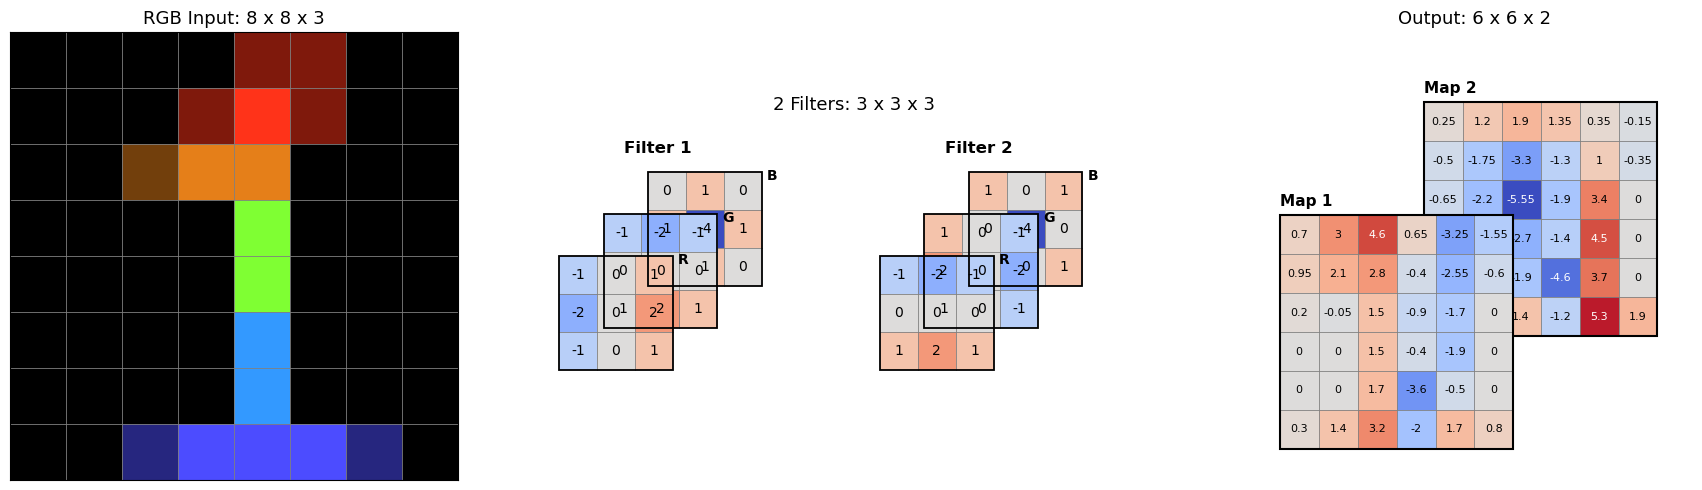

输入尺寸: (1, 3, 8, 8)
卷积层权重尺寸: (2, 3, 3, 3)
输出尺寸: (1, 2, 6, 6)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [22]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display, Math

# 1. 构造 8×8 手写数字 1
image = torch.tensor([
    [0,0,0,0,0.5,0.5,0,0],
    [0,0,0,0.5,1,0.5,0,0],
    [0,0,0.5,1,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0.5,1,1,1,0.5,0]
], dtype=torch.float32)

# 2. 生成 RGB 彩色图像
row_colors = torch.tensor([
    [1.0,0.2,0.1],
    [1.0,0.2,0.1],
    [0.9,0.5,0.1],
    [0.5,1.0,0.2],
    [0.5,1.0,0.2],
    [0.2,0.6,1.0],
    [0.2,0.6,1.0],
    [0.3,0.3,1.0]
], dtype=torch.float32)

rgb = image.unsqueeze(-1) * row_colors.unsqueeze(1)
x = rgb.permute(2,0,1).unsqueeze(0)  # [1,3,8,8]

# 3. 定义两个 Filter，每个 Filter 包含 R、G、B 三个 3×3 卷积核
K1_R = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32)
K1_G = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32)
K1_B = torch.tensor([[0,1,0],[1,-4,1],[0,1,0]], dtype=torch.float32)

K2_R = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32)
K2_G = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=torch.float32)
K2_B = torch.tensor([[1,0,1],[0,-4,0],[1,0,1]], dtype=torch.float32)

filter1 = torch.stack([K1_R,K1_G,K1_B])
filter2 = torch.stack([K2_R,K2_G,K2_B])

# 4. 卷积层：3 个输入通道，2 个 Filter
conv2 = nn.Conv2d(in_channels=3, out_channels=2, kernel_size=3, stride=1, padding=0, bias=False)

with torch.no_grad():
    conv2.weight.copy_(torch.stack([filter1,filter2]))
    y2 = conv2(x)

    # Filter 1：三个通道分别卷积
    F1_R = F.conv2d(x[:,0:1], K1_R.reshape(1,1,3,3))[0,0]
    F1_G = F.conv2d(x[:,1:2], K1_G.reshape(1,1,3,3))[0,0]
    F1_B = F.conv2d(x[:,2:3], K1_B.reshape(1,1,3,3))[0,0]

    # Filter 2：三个通道分别卷积
    F2_R = F.conv2d(x[:,0:1], K2_R.reshape(1,1,3,3))[0,0]
    F2_G = F.conv2d(x[:,1:2], K2_G.reshape(1,1,3,3))[0,0]
    F2_B = F.conv2d(x[:,2:3], K2_B.reshape(1,1,3,3))[0,0]

    # 验证两个 Filter 的输出
    assert torch.allclose(y2[0,0], F1_R+F1_G+F1_B)
    assert torch.allclose(y2[0,1], F2_R+F2_G+F2_B)

# 5. 绘制原始 RGB 图片
def show_rgb(ax, data, title):
    a = data.detach().cpu().numpy()
    ax.imshow(a)
    ax.set_xticks(np.arange(-0.5,a.shape[1],1),minor=True)
    ax.set_yticks(np.arange(-0.5,a.shape[0],1),minor=True)
    ax.grid(which="minor",color="gray",linewidth=0.6)
    ax.tick_params(which="both",bottom=False,left=False,labelbottom=False,labelleft=False)
    ax.set_title(title,fontsize=13)

# 6. 绘制两个 Filter 内部的三个卷积核
def show_filters(ax, filters, title):
    arrays = [f.detach().cpu().numpy() for f in filters]
    vmax = max(1,max(np.abs(a).max() for a in arrays))
    size = 0.46
    channels = ["R","G","B"]

    for f_idx, a in enumerate(arrays):
        base_x = 0.08 + f_idx*1.30

        for c in [2,1,0]:
            ox, oy = base_x+c*0.18, 0.10+c*0.17
            z = 3-c
            matrix = a[c]

            ax.imshow(matrix,cmap="coolwarm",vmin=-vmax,vmax=vmax,origin="upper",
                      extent=(ox,ox+size,oy,oy+size),zorder=z)

            for k in range(1,3):
                xx = ox+k*size/3
                yy = oy+k*size/3
                ax.plot([xx,xx],[oy,oy+size],color="gray",linewidth=0.6,zorder=z+1)
                ax.plot([ox,ox+size],[yy,yy],color="gray",linewidth=0.6,zorder=z+1)

            for i in range(3):
                for j in range(3):
                    value = matrix[i,j]
                    xx = ox+(j+0.5)*size/3
                    yy = oy+size-(i+0.5)*size/3
                    ax.text(xx,yy,f"{value:g}",ha="center",va="center",
                            fontsize=10,color="black",zorder=z+2)

            ax.add_patch(plt.Rectangle((ox,oy),size,size,fill=False,
                                       edgecolor="black",linewidth=1.3,zorder=z+3))
            ax.text(ox+size+0.02,oy+size-0.03,channels[c],fontsize=10,
                    weight="bold",zorder=z+4)

        ax.text(base_x+0.40,0.98,f"Filter {f_idx+1}",ha="center",
                fontsize=12,weight="bold")

    ax.set_xlim(0,2.55)
    ax.set_ylim(0,1.12)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title,fontsize=13)

# 7. 绘制两张输出特征图，错位堆叠并显示数值
def show_stack(ax, matrices, title, labels):
    arrays = [m.detach().cpu().numpy() for m in matrices]
    vmax = max(1,max(np.abs(a).max() for a in arrays))
    cmap = plt.get_cmap("coolwarm")
    size = 0.60
    positions = [(0.06,0.08),(0.43,0.37)]

    for idx in [1,0]:
        a = arrays[idx]
        ox,oy = positions[idx]
        z = 1 if idx==1 else 5
        rows,cols = a.shape

        ax.imshow(a,cmap="coolwarm",vmin=-vmax,vmax=vmax,origin="upper",
                  extent=(ox,ox+size,oy,oy+size),zorder=z)

        for k in range(1,cols):
            xx = ox+k*size/cols
            ax.plot([xx,xx],[oy,oy+size],color="gray",linewidth=0.6,zorder=z+1)

        for k in range(1,rows):
            yy = oy+k*size/rows
            ax.plot([ox,ox+size],[yy,yy],color="gray",linewidth=0.6,zorder=z+1)

        for i in range(rows):
            for j in range(cols):
                value = a[i,j]
                xx = ox+(j+0.5)*size/cols
                yy = oy+size-(i+0.5)*size/rows
                r,g,b,_ = cmap((value+vmax)/(2*vmax))
                color = "white" if 0.2126*r+0.7152*g+0.0722*b < 0.48 else "black"
                ax.text(xx,yy,f"{value:g}",ha="center",va="center",
                        fontsize=8,color=color,zorder=z+2)

        ax.add_patch(plt.Rectangle((ox,oy),size,size,fill=False,
                                   edgecolor="black",linewidth=1.5,zorder=z+3))
        ax.text(ox,oy+size+0.025,labels[idx],fontsize=11,weight="bold",zorder=z+3)

    ax.set_xlim(0,1.12)
    ax.set_ylim(0,1.15)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title,fontsize=13)

# 8. 在同一行绘制三个图
fig, axes = plt.subplots(1,3,figsize=(19,5))

rgb_image = x[0].permute(1,2,0)
show_rgb(axes[0],rgb_image,"RGB Input: 8 x 8 x 3")
show_filters(axes[1],[filter1,filter2],"2 Filters: 3 x 3 x 3")
show_stack(axes[2],[y2[0,0],y2[0,1]],"Output: 6 x 6 x 2",["Map 1","Map 2"])

plt.tight_layout()
plt.show()

# 9. 输出各阶段尺寸
print("输入尺寸:",tuple(x.shape))
print("卷积层权重尺寸:",tuple(conv2.weight.shape))
print("输出尺寸:",tuple(y2.shape))

# 10. 将 PyTorch Tensor 转换为 LaTeX 矩阵
def to_latex_matrix(tensor):
    a = tensor.detach().cpu().numpy()
    rows = [" & ".join(f"{v:.4g}" for v in row) for row in a]
    return r"\begin{bmatrix}" + r"\\".join(rows) + r"\end{bmatrix}"

# 11. LaTeX 显示原始输入矩阵
display(Math(r"\text{Original Input Matrix: } 8\times8"))
display(Math(rf"I={to_latex_matrix(image)}"))

# 12. LaTeX 显示 RGB 三个输入矩阵（横向排列）
display(Math(r"\text{RGB Input Matrices: } 8\times8\times3"))
display(Math(
    rf"\scriptsize R={to_latex_matrix(x[0,0])}"
    rf"\qquad G={to_latex_matrix(x[0,1])}"
    rf"\qquad B={to_latex_matrix(x[0,2])}"
))

# 13. LaTeX 显示 Filter 1 的三个卷积核（横向排列）
display(Math(r"\text{Filter 1: RGB Kernels}"))
display(Math(
    rf"K_{{1,R}}={to_latex_matrix(K1_R)}"
    rf"\qquad K_{{1,G}}={to_latex_matrix(K1_G)}"
    rf"\qquad K_{{1,B}}={to_latex_matrix(K1_B)}"
))

# 14. LaTeX 显示 Filter 2 的三个卷积核（横向排列）
display(Math(r"\text{Filter 2: RGB Kernels}"))
display(Math(
    rf"K_{{2,R}}={to_latex_matrix(K2_R)}"
    rf"\qquad K_{{2,G}}={to_latex_matrix(K2_G)}"
    rf"\qquad K_{{2,B}}={to_latex_matrix(K2_B)}"
))

# 15. LaTeX 显示 Filter 1 的三个通道卷积结果（横向排列）
display(Math(r"\text{Filter 1: Convolution Output of Each Channel}"))
display(Math(
    rf"\scriptsize F_{{1,R}}={to_latex_matrix(F1_R)}"
    rf"\qquad F_{{1,G}}={to_latex_matrix(F1_G)}"
    rf"\qquad F_{{1,B}}={to_latex_matrix(F1_B)}"
))

# 16. LaTeX 显示 Filter 2 的三个通道卷积结果（横向排列）
display(Math(r"\text{Filter 2: Convolution Output of Each Channel}"))
display(Math(
    rf"\scriptsize F_{{2,R}}={to_latex_matrix(F2_R)}"
    rf"\qquad F_{{2,G}}={to_latex_matrix(F2_G)}"
    rf"\qquad F_{{2,B}}={to_latex_matrix(F2_B)}"
))

# 17. LaTeX 显示两个 Filter 的计算公式
display(Math(r"\text{Convolution Operations}"))
display(Math(r"F_1=F_{1,R}+F_{1,G}+F_{1,B}"))
display(Math(r"F_2=F_{2,R}+F_{2,G}+F_{2,B}"))

# 18. LaTeX 显示两个最终输出特征图矩阵（横向排列）
display(Math(r"\text{Final Output Feature Maps: } 6\times6\times2"))
display(Math(
    rf"\scriptsize F_1={to_latex_matrix(y2[0,0])}"
    rf"\qquad F_2={to_latex_matrix(y2[0,1])}"
))

增加ReLU+最大池化层+Flatten+Linear

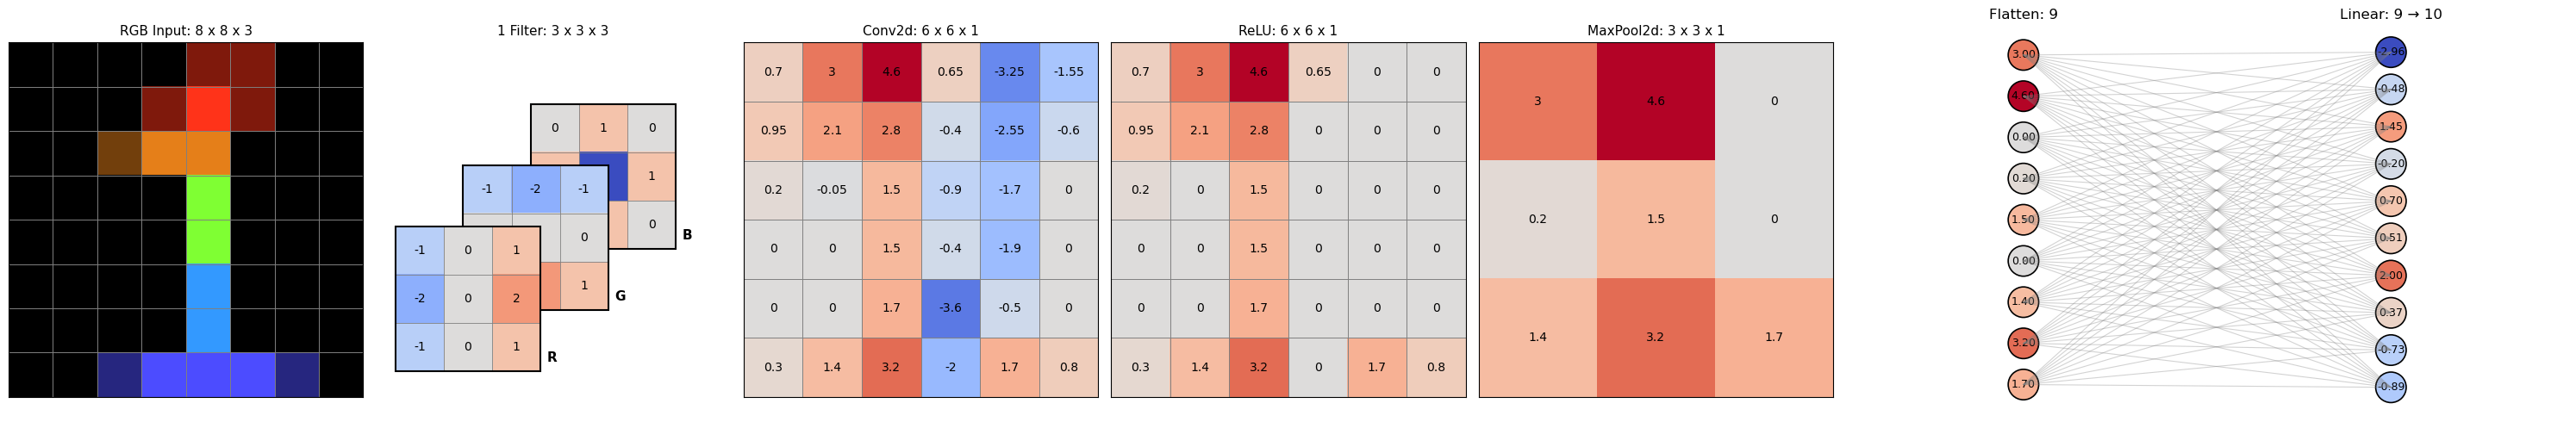

输入尺寸: (1, 3, 8, 8)
卷积层权重尺寸: (1, 3, 3, 3)
卷积输出尺寸: (1, 1, 6, 6)
ReLU 输出尺寸: (1, 1, 6, 6)
最大池化输出尺寸: (1, 1, 3, 3)
Flatten 输出尺寸: (1, 9)
Linear 输出尺寸: (1, 10)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [23]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from IPython.display import display, Math

torch.manual_seed(0)

# 1. 构造 8×8 手写数字 1
image = torch.tensor([
    [0,0,0,0,0.5,0.5,0,0],
    [0,0,0,0.5,1,0.5,0,0],
    [0,0,0.5,1,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0.5,1,1,1,0.5,0]
], dtype=torch.float32)

# 2. 给数字的不同位置设置 RGB 颜色
row_colors = torch.tensor([
    [1.0,0.2,0.1],
    [1.0,0.2,0.1],
    [0.9,0.5,0.1],
    [0.5,1.0,0.2],
    [0.5,1.0,0.2],
    [0.2,0.6,1.0],
    [0.2,0.6,1.0],
    [0.3,0.3,1.0]
], dtype=torch.float32)

rgb = image.unsqueeze(-1) * row_colors.unsqueeze(1)
x_rgb = rgb.permute(2,0,1).unsqueeze(0)  # [1,3,8,8]

# 3. 定义一个 Filter，内部包含三个 3×3 卷积核
kernel_R = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32)
kernel_G = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32)
kernel_B = torch.tensor([[0,1,0],[1,-4,1],[0,1,0]], dtype=torch.float32)

kernels = torch.stack([kernel_R,kernel_G,kernel_B])
conv1 = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, stride=1, padding=0, bias=False)

# 4. 定义 ReLU、最大池化、Flatten 和 Linear
relu = nn.ReLU()
pool = nn.MaxPool2d(kernel_size=2, stride=2)
flatten = nn.Flatten()
linear = nn.Linear(in_features=9, out_features=10, bias=True)

with torch.no_grad():
    conv1.weight.copy_(kernels.unsqueeze(0))
    y1 = conv1(x_rgb)
    y_relu = relu(y1)
    y_pool = pool(y_relu)
    y_flat = flatten(y_pool)
    y_linear = linear(y_flat)

    # 分别计算 RGB 三个通道的卷积贡献，用于验证
    F_R = F.conv2d(x_rgb[:,0:1],kernel_R.reshape(1,1,3,3))[0,0]
    F_G = F.conv2d(x_rgb[:,1:2],kernel_G.reshape(1,1,3,3))[0,0]
    F_B = F.conv2d(x_rgb[:,2:3],kernel_B.reshape(1,1,3,3))[0,0]
    assert torch.allclose(y1[0,0],F_R+F_G+F_B)

# 5. 绘制 RGB 原始图片
def show_rgb(ax, data, title):
    a = data.detach().cpu().numpy()
    ax.imshow(a)
    ax.set_xticks(np.arange(-0.5,a.shape[1],1),minor=True)
    ax.set_yticks(np.arange(-0.5,a.shape[0],1),minor=True)
    ax.grid(which="minor",color="gray",linewidth=0.7)
    ax.tick_params(which="both",bottom=False,left=False,labelbottom=False,labelleft=False)
    ax.set_title(title,fontsize=11)

# 6. 绘制矩阵，每个位置显示实际数值
def show_matrix(ax, data, title):
    a = data.detach().cpu().numpy()
    vmax = max(1,np.abs(a).max())
    ax.imshow(a,cmap="coolwarm",vmin=-vmax,vmax=vmax)

    for i in range(a.shape[0]):
        for j in range(a.shape[1]):
            ax.text(j,i,f"{a[i,j]:g}",ha="center",va="center",fontsize=10,color="black")

    ax.set_xticks(np.arange(-0.5,a.shape[1],1),minor=True)
    ax.set_yticks(np.arange(-0.5,a.shape[0],1),minor=True)
    ax.grid(which="minor",color="gray",linewidth=0.7)
    ax.tick_params(which="both",bottom=False,left=False,labelbottom=False,labelleft=False)
    ax.set_title(title,fontsize=11)

# 7. 绘制一个 Filter 内部的三个卷积核，错位堆叠显示数值
def show_filter(ax, kernels, title):
    arrays = [k.detach().cpu().numpy() for k in kernels]
    vmax = max(1,max(np.abs(a).max() for a in arrays))
    cmap = plt.get_cmap("coolwarm")
    size = 0.45
    positions = [(0.06,0.08),(0.27,0.27),(0.48,0.46)]
    labels = ["R","G","B"]

    for idx in [2,1,0]:
        a = arrays[idx]
        ox,oy = positions[idx]
        z = 2+4*(2-idx)

        ax.imshow(a,cmap="coolwarm",vmin=-vmax,vmax=vmax,origin="upper",
                  extent=(ox,ox+size,oy,oy+size),zorder=z)

        for k in range(1,3):
            xx = ox+k*size/3
            yy = oy+k*size/3
            ax.plot([xx,xx],[oy,oy+size],color="gray",linewidth=0.6,zorder=z+1)
            ax.plot([ox,ox+size],[yy,yy],color="gray",linewidth=0.6,zorder=z+1)

        for i in range(3):
            for j in range(3):
                value = a[i,j]
                xx = ox+(j+0.5)*size/3
                yy = oy+size-(i+0.5)*size/3
                ax.text(xx,yy,f"{value:g}",ha="center",va="center",
                        fontsize=10,color="black",zorder=z+2)

        ax.add_patch(plt.Rectangle((ox,oy),size,size,fill=False,
                                  edgecolor="black",linewidth=1.5,zorder=z+3))
        ax.text(ox+size+0.02,oy+0.03,labels[idx],fontsize=11,weight="bold",zorder=z+4)

    ax.set_xlim(0,1.10)
    ax.set_ylim(0,1.10)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title,fontsize=11)

# 8. 绘制神经元，圆圈内显示数值
def show_neurons(ax, data, title):
    a = data.detach().cpu().numpy().flatten()
    n = len(a)
    ys = np.arange(n)[::-1]
    vmax = max(1,np.abs(a).max())

    ax.scatter(np.zeros(n),ys,c=a,cmap="coolwarm",vmin=-vmax,vmax=vmax,
               s=650,edgecolors="black",linewidths=1.2,zorder=3)

    for i,value in enumerate(a):
        ax.text(0,ys[i],f"{value:.2f}",ha="center",va="center",fontsize=9,zorder=4)

    ax.set_xlim(-0.8,0.8)
    ax.set_ylim(-0.7,n-0.3)
    ax.set_aspect("auto")
    ax.axis("off")
    ax.set_title(title,fontsize=12)
    return np.zeros(n),ys

# 9. 在同一行绘制七个图
fig,axes = plt.subplots(1,7,figsize=(30,5))

show_rgb(axes[0],rgb,"RGB Input: 8 x 8 x 3")
show_filter(axes[1],[kernel_R,kernel_G,kernel_B],"1 Filter: 3 x 3 x 3")
show_matrix(axes[2],y1[0,0],"Conv2d: 6 x 6 x 1")
show_matrix(axes[3],y_relu[0,0],"ReLU: 6 x 6 x 1")
show_matrix(axes[4],y_pool[0,0],"MaxPool2d: 3 x 3 x 1")

x1s,y1s = show_neurons(axes[5],y_flat[0],"Flatten: 9")
x2s,y2s = show_neurons(axes[6],y_linear[0],"Linear: 9 → 10")

plt.tight_layout()

# 10. 在 Flatten 和 Linear 之间添加全连接线
for y_left in y1s:
    for y_right in y2s:
        con = ConnectionPatch(xyA=(0,y_left),coordsA=axes[5].transData,
                              xyB=(0,y_right),coordsB=axes[6].transData,
                              color="gray",alpha=0.35,linewidth=0.8,zorder=1)
        fig.add_artist(con)

plt.show()

# 11. 输出各阶段尺寸
print("输入尺寸:",tuple(x_rgb.shape))
print("卷积层权重尺寸:",tuple(conv1.weight.shape))
print("卷积输出尺寸:",tuple(y1.shape))
print("ReLU 输出尺寸:",tuple(y_relu.shape))
print("最大池化输出尺寸:",tuple(y_pool.shape))
print("Flatten 输出尺寸:",tuple(y_flat.shape))
print("Linear 输出尺寸:",tuple(y_linear.shape))

# 12. 将 PyTorch Tensor 转换为 LaTeX 矩阵
def to_latex_matrix(tensor):
    a = tensor.detach().cpu().numpy()
    if a.ndim == 1:
        a = a.reshape(1,-1)
    rows = [" & ".join(f"{v:.4g}" for v in row) for row in a]
    return r"\begin{bmatrix}" + r"\\".join(rows) + r"\end{bmatrix}"

# 13. LaTeX 显示 Filter 内部的三个卷积核
display(Math(r"\text{RGB Filter: Three Convolution Kernels}"))
display(Math(rf"K_R={to_latex_matrix(kernel_R)} \qquad K_G={to_latex_matrix(kernel_G)} \qquad K_B={to_latex_matrix(kernel_B)}"))

# 14. LaTeX 显示三个通道的卷积结果
display(Math(r"\text{Convolution Output of Each RGB Channel}"))
display(Math(rf"F_R={to_latex_matrix(F_R)}"))
display(Math(rf"F_G={to_latex_matrix(F_G)}"))
display(Math(rf"F_B={to_latex_matrix(F_B)}"))

# 15. LaTeX 显示最终卷积输出
display(Math(r"\text{Final Convolution Output}"))
display(Math(r"F=F_R+F_G+F_B"))
display(Math(rf"F={to_latex_matrix(y1[0,0])}"))

# 16. LaTeX 显示 ReLU 输出
display(Math(r"\text{ReLU Output}"))
display(Math(rf"F_{{\mathrm{{ReLU}}}}={to_latex_matrix(y_relu[0,0])}"))

# 17. LaTeX 显示最大池化输出
display(Math(r"\text{Max Pooling Output}"))
display(Math(rf"F_{{\mathrm{{Pool}}}}={to_latex_matrix(y_pool[0,0])}"))

# 18. LaTeX 显示 Flatten 输出
display(Math(r"\text{Flatten Output}"))
display(Math(rf"F_{{\mathrm{{Flat}}}}={to_latex_matrix(y_flat[0])}"))

# 19. LaTeX 显示 Linear 输出
display(Math(r"\text{Linear Output}"))
display(Math(rf"F_{{\mathrm{{Linear}}}}={to_latex_matrix(y_linear[0])}"))

两个卷积核

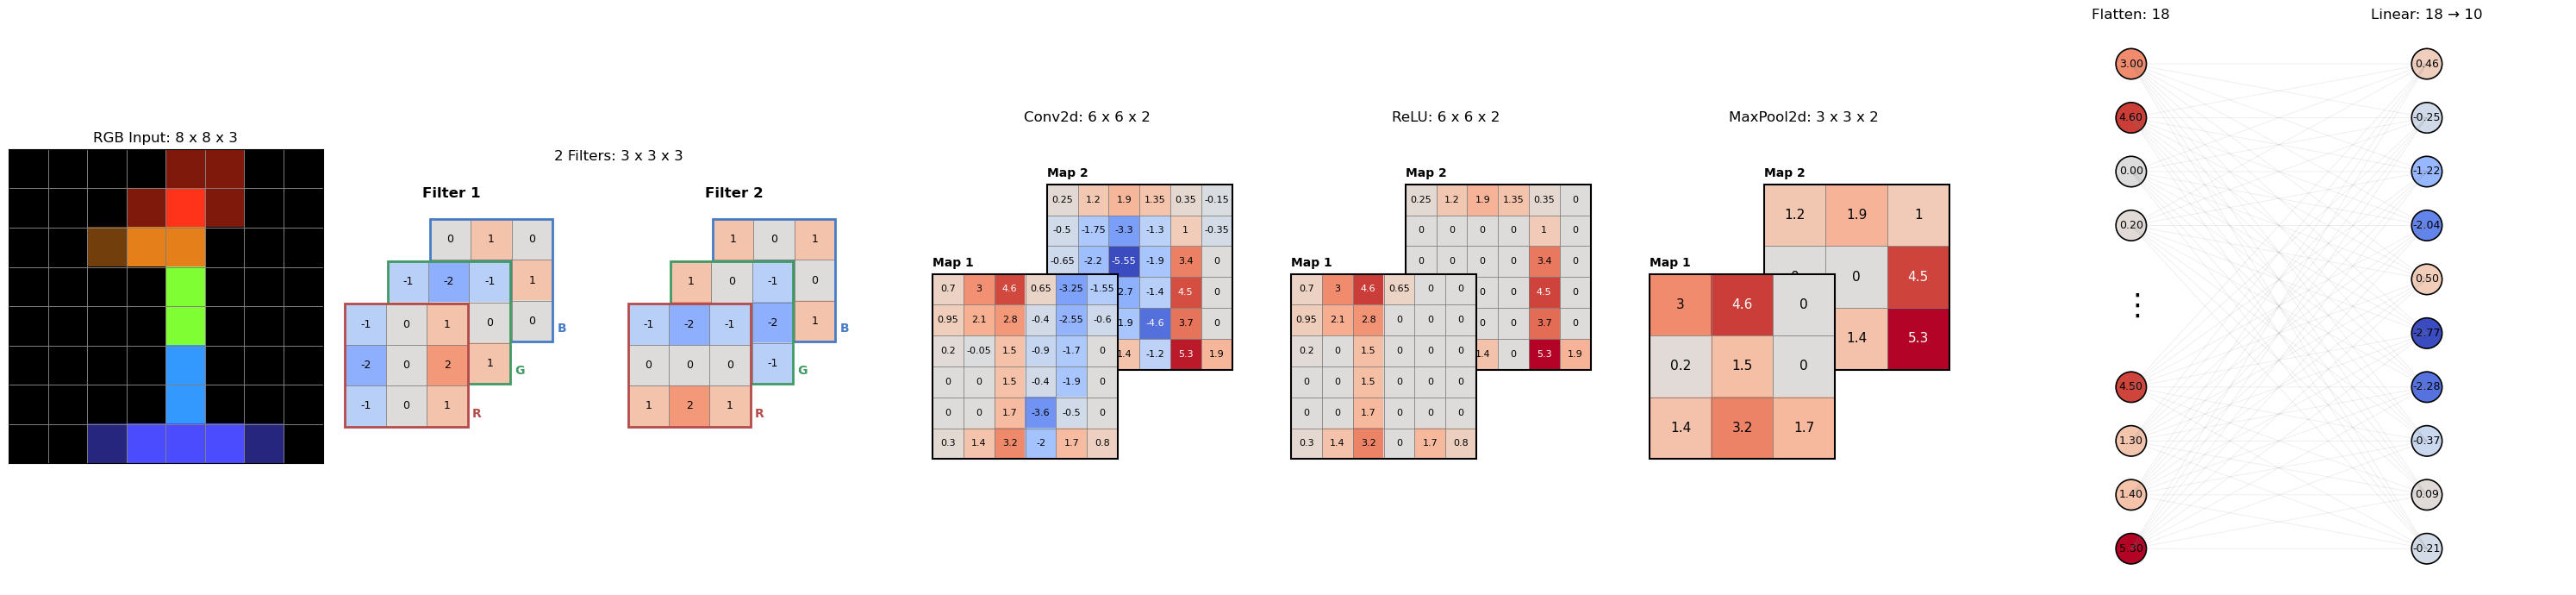

RGB 输入尺寸: (1, 3, 8, 8)
卷积层权重尺寸: (2, 3, 3, 3)
卷积输出尺寸: (1, 2, 6, 6)
ReLU 输出尺寸: (1, 2, 6, 6)
最大池化输出尺寸: (1, 2, 3, 3)
Flatten 输出尺寸: (1, 18)
Linear 输出尺寸: (1, 10)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [24]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from IPython.display import display, Math

torch.manual_seed(0)

# 1. 构造 8×8 手写数字 1，并设置 RGB 颜色
image = torch.tensor([
    [0,0,0,0,0.5,0.5,0,0],
    [0,0,0,0.5,1,0.5,0,0],
    [0,0,0.5,1,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,0.5,1,1,1,0.5,0]
], dtype=torch.float32)

row_colors = torch.tensor([
    [1.0,0.2,0.1],
    [1.0,0.2,0.1],
    [0.9,0.5,0.1],
    [0.5,1.0,0.2],
    [0.5,1.0,0.2],
    [0.2,0.6,1.0],
    [0.2,0.6,1.0],
    [0.3,0.3,1.0]
], dtype=torch.float32)

rgb = image.unsqueeze(-1) * row_colors.unsqueeze(1)
x_rgb = rgb.permute(2,0,1).unsqueeze(0)  # [1,3,8,8]

# 2. 定义两个 Filter，每个包含 R、G、B 三个 3×3 卷积核
K1_R = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32)
K1_G = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32)
K1_B = torch.tensor([[0,1,0],[1,-4,1],[0,1,0]], dtype=torch.float32)

K2_R = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32)
K2_G = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=torch.float32)
K2_B = torch.tensor([[1,0,1],[0,-4,0],[1,0,1]], dtype=torch.float32)

filter1 = torch.stack([K1_R,K1_G,K1_B])
filter2 = torch.stack([K2_R,K2_G,K2_B])

# 3. 定义卷积层：3 个输入通道，2 个 Filter
conv2 = nn.Conv2d(in_channels=3, out_channels=2, kernel_size=3, stride=1, padding=0, bias=False)

# 4. 定义 ReLU、最大池化、Flatten 和 Linear
relu2 = nn.ReLU()
pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
flatten2 = nn.Flatten()
linear2 = nn.Linear(in_features=18, out_features=10, bias=True)

with torch.no_grad():
    conv2.weight.copy_(torch.stack([filter1,filter2]))
    y2 = conv2(x_rgb)
    y_relu2 = relu2(y2)
    y_pool2 = pool2(y_relu2)
    y_flat2 = flatten2(y_pool2)
    y_linear2 = linear2(y_flat2)

# 5. 绘制 RGB 原始图片
def show_rgb(ax, data, title):
    a = data.detach().cpu().numpy()
    ax.imshow(a)
    ax.set_xticks(np.arange(-0.5,a.shape[1],1),minor=True)
    ax.set_yticks(np.arange(-0.5,a.shape[0],1),minor=True)
    ax.grid(which="minor",color="gray",linewidth=0.7)
    ax.tick_params(which="both",bottom=False,left=False,labelbottom=False,labelleft=False)
    ax.set_title(title,fontsize=12)

# 6. 绘制单通道矩阵，显示每个像素的数值
def show_matrix(ax, data, title):
    a = data.detach().cpu().numpy()
    vmax = max(1,np.abs(a).max())
    ax.imshow(a,cmap="coolwarm",vmin=-vmax,vmax=vmax)

    for i in range(a.shape[0]):
        for j in range(a.shape[1]):
            ax.text(j,i,f"{a[i,j]:g}",ha="center",va="center",fontsize=10,color="black")

    ax.set_xticks(np.arange(-0.5,a.shape[1],1),minor=True)
    ax.set_yticks(np.arange(-0.5,a.shape[0],1),minor=True)
    ax.grid(which="minor",color="gray",linewidth=0.7)
    ax.tick_params(which="both",bottom=False,left=False,labelbottom=False,labelleft=False)
    ax.set_title(title,fontsize=12)

# 7. 绘制两个 Filter，每个 Filter 内部的三个卷积核错位堆叠
def show_filters(ax, filters, title):
    arrays = [f.detach().cpu().numpy() for f in filters]
    vmax = max(1,max(np.abs(a).max() for a in arrays))
    cmap = plt.get_cmap("coolwarm")
    size = 0.52
    labels = ["R","G","B"]
    border_colors = ["#b54b4b","#3f9a63","#467bc5"]

    for f_idx, a in enumerate(arrays):
        base_x = 0.04 + f_idx*1.20

        for c in [2,1,0]:
            ox,oy = base_x+c*0.18,0.08+c*0.18
            z = 10-3*c
            matrix = a[c]

            ax.imshow(matrix,cmap="coolwarm",vmin=-vmax,vmax=vmax,origin="upper",
                      extent=(ox,ox+size,oy,oy+size),zorder=z)

            for k in range(1,3):
                xx = ox+k*size/3
                yy = oy+k*size/3
                ax.plot([xx,xx],[oy,oy+size],color="gray",linewidth=0.6,zorder=z+1)
                ax.plot([ox,ox+size],[yy,yy],color="gray",linewidth=0.6,zorder=z+1)

            for i in range(3):
                for j in range(3):
                    value = matrix[i,j]
                    xx = ox+(j+0.5)*size/3
                    yy = oy+size-(i+0.5)*size/3
                    r,g,b,_ = cmap((value+vmax)/(2*vmax))
                    color = "white" if 0.2126*r+0.7152*g+0.0722*b < 0.48 else "black"
                    ax.text(xx,yy,f"{value:g}",ha="center",va="center",
                            fontsize=9,color=color,zorder=z+2)

            ax.add_patch(plt.Rectangle((ox,oy),size,size,fill=False,
                                       edgecolor=border_colors[c],linewidth=2,zorder=z+3))
            ax.text(ox+size+0.02,oy+0.04,labels[c],fontsize=10,
                    weight="bold",color=border_colors[c],zorder=z+4)

        ax.text(base_x+0.45,1.05,f"Filter {f_idx+1}",ha="center",fontsize=12,weight="bold")

    ax.set_xlim(0,2.40)
    ax.set_ylim(0,1.18)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title,fontsize=12)

# 8. 绘制两张特征图，错位堆叠并显示数值
def show_stack(ax, matrices, title, labels):
    arrays = [m.detach().cpu().numpy() for m in matrices]
    vmax = max(1,max(np.abs(a).max() for a in arrays))
    cmap = plt.get_cmap("coolwarm")
    size = 0.60
    positions = [(0.06,0.08),(0.43,0.37)]

    for idx in [1,0]:
        a = arrays[idx]
        ox,oy = positions[idx]
        z = 1 if idx==1 else 5
        rows,cols = a.shape

        ax.imshow(a,cmap="coolwarm",vmin=-vmax,vmax=vmax,origin="upper",
                  extent=(ox,ox+size,oy,oy+size),zorder=z)

        for k in range(1,cols):
            xx = ox+k*size/cols
            ax.plot([xx,xx],[oy,oy+size],color="gray",linewidth=0.6,zorder=z+1)

        for k in range(1,rows):
            yy = oy+k*size/rows
            ax.plot([ox,ox+size],[yy,yy],color="gray",linewidth=0.6,zorder=z+1)

        for i in range(rows):
            for j in range(cols):
                value = a[i,j]
                xx = ox+(j+0.5)*size/cols
                yy = oy+size-(i+0.5)*size/rows
                r,g,b,_ = cmap((value+vmax)/(2*vmax))
                color = "white" if 0.2126*r+0.7152*g+0.0722*b < 0.48 else "black"
                ax.text(xx,yy,f"{value:g}",ha="center",va="center",
                        fontsize=11 if rows==3 else 8,color=color,zorder=z+2)

        ax.add_patch(plt.Rectangle((ox,oy),size,size,fill=False,
                                  edgecolor="black",linewidth=1.5,zorder=z+3))
        ax.text(ox,oy+size+0.025,labels[idx],fontsize=10,weight="bold",zorder=z+3)

    ax.set_xlim(0,1.12)
    ax.set_ylim(0,1.15)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title,fontsize=12)

# 9. 绘制神经元，超过 12 个时省略中间部分
def show_neurons(ax, data, title):
    a = data.detach().cpu().numpy().flatten()
    n = len(a)
    vmax = max(1,np.abs(a).max())

    if n > 12:
        indices = list(range(4)) + list(range(n-4,n))
        ys = np.array([9,8,7,6,3,2,1,0])
        ax.text(0,4.5,r"$\vdots$",ha="center",va="center",fontsize=25)
    else:
        indices = list(range(n))
        ys = np.arange(n)[::-1]

    values = a[indices]
    ax.scatter(np.zeros(len(indices)),ys,c=values,cmap="coolwarm",
               vmin=-vmax,vmax=vmax,s=650,edgecolors="black",linewidths=1.2,zorder=3)

    for i,value in enumerate(values):
        ax.text(0,ys[i],f"{value:.2f}",ha="center",va="center",fontsize=9,zorder=4)

    ax.set_xlim(-0.8,0.8)
    ax.set_ylim(-0.7,max(9,n-1 if n<=12 else 9)+0.7)
    ax.set_aspect("auto")
    ax.axis("off")
    ax.set_title(title,fontsize=12)
    return np.zeros(len(indices)),ys

# 10. 在同一行绘制七个图
fig,axes = plt.subplots(1,7,figsize=(30,7),
                       gridspec_kw={"width_ratios":[1,1.8,1.1,1.1,1.1,0.9,0.9]})

show_rgb(axes[0],rgb,"RGB Input: 8 x 8 x 3")
show_filters(axes[1],[filter1,filter2],"2 Filters: 3 x 3 x 3")
show_stack(axes[2],[y2[0,0],y2[0,1]],"Conv2d: 6 x 6 x 2",["Map 1","Map 2"])
show_stack(axes[3],[y_relu2[0,0],y_relu2[0,1]],"ReLU: 6 x 6 x 2",["Map 1","Map 2"])
show_stack(axes[4],[y_pool2[0,0],y_pool2[0,1]],"MaxPool2d: 3 x 3 x 2",["Map 1","Map 2"])

# Flatten 和 Linear 使用竖直圆圈
x1s,y1s = show_neurons(axes[5],y_flat2[0],"Flatten: 18")
x2s,y2s = show_neurons(axes[6],y_linear2[0],"Linear: 18 → 10")

plt.tight_layout()

# 11. 绘制可见神经元之间的全连接线；实际权重共有 18×10=180 个
for y_left in y1s:
    for y_right in y2s:
        con = ConnectionPatch(xyA=(0,y_left),coordsA=axes[5].transData,
                              xyB=(0,y_right),coordsB=axes[6].transData,
                              color="gray",alpha=0.15,linewidth=0.6,zorder=1)
        fig.add_artist(con)

plt.show()

# 12. 输出各阶段尺寸
print("RGB 输入尺寸:",tuple(x_rgb.shape))
print("卷积层权重尺寸:",tuple(conv2.weight.shape))
print("卷积输出尺寸:",tuple(y2.shape))
print("ReLU 输出尺寸:",tuple(y_relu2.shape))
print("最大池化输出尺寸:",tuple(y_pool2.shape))
print("Flatten 输出尺寸:",tuple(y_flat2.shape))
print("Linear 输出尺寸:",tuple(y_linear2.shape))

# 13. 将 PyTorch Tensor 转换为 LaTeX 矩阵
def to_latex_matrix(tensor):
    a = tensor.detach().cpu().numpy()
    if a.ndim == 1:
        a = a.reshape(1,-1)
    rows = [" & ".join(f"{v:.4g}" for v in row) for row in a]
    return r"\begin{bmatrix}" + r"\\".join(rows) + r"\end{bmatrix}"

# 14. LaTeX 显示第一个 Filter 的三个卷积核
display(Math(r"\text{Filter 1: RGB Kernels}"))
display(Math(rf"K_{{1,R}}={to_latex_matrix(K1_R)} \qquad K_{{1,G}}={to_latex_matrix(K1_G)} \qquad K_{{1,B}}={to_latex_matrix(K1_B)}"))

# 15. LaTeX 显示第二个 Filter 的三个卷积核
display(Math(r"\text{Filter 2: RGB Kernels}"))
display(Math(rf"K_{{2,R}}={to_latex_matrix(K2_R)} \qquad K_{{2,G}}={to_latex_matrix(K2_G)} \qquad K_{{2,B}}={to_latex_matrix(K2_B)}"))

# 16. LaTeX 显示两个卷积输出矩阵
display(Math(r"\text{Convolution Output}"))
display(Math(r"F_1=R*K_{1,R}+G*K_{1,G}+B*K_{1,B}"))
display(Math(r"F_2=R*K_{2,R}+G*K_{2,G}+B*K_{2,B}"))
display(Math(rf"F_1={to_latex_matrix(y2[0,0])} \qquad F_2={to_latex_matrix(y2[0,1])}"))

# 17. LaTeX 显示两个 ReLU 输出矩阵
display(Math(r"\text{ReLU Output}"))
display(Math(rf"F_{{\mathrm{{ReLU}},1}}={to_latex_matrix(y_relu2[0,0])} \qquad F_{{\mathrm{{ReLU}},2}}={to_latex_matrix(y_relu2[0,1])}"))

# 18. LaTeX 显示两个最大池化输出矩阵
display(Math(r"\text{Max Pooling Output}"))
display(Math(rf"F_{{\mathrm{{Pool}},1}}={to_latex_matrix(y_pool2[0,0])} \qquad F_{{\mathrm{{Pool}},2}}={to_latex_matrix(y_pool2[0,1])}"))

# 19. LaTeX 显示 Flatten 输出的 18 维向量
display(Math(r"\text{Flatten Output}"))
display(Math(rf"F_{{\mathrm{{Flat}}}}={to_latex_matrix(y_flat2[0])}"))

# 20. LaTeX 显示 Linear 输出的 10 维向量
display(Math(r"\text{Linear Output}"))
display(Math(rf"F_{{\mathrm{{Linear}}}}={to_latex_matrix(y_linear2[0])}"))